# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Guntur Budi Santoso
- **Email:** budiibos0618@gmail.com
- **ID Dicoding:** CDCC899D6Y1679

## Menentukan Pertanyaan Bisnis

### **Pertanyaan 1: Bagaimana tren bulanan jumlah pesanan dan total pendapatan sepanjang tahun 2017 hingga 2018, serta bulan apa yang mencatat performa tertinggi dan terendah?**

---

### **Pertanyaan 2: Kategori produk apa saja yang menyumbang minimal 80% dari total pendapatan selama periode 2017-2018, dan bagaimana perbandingan volume penjualan antar kategori tersebut?**

---

### **Pertanyaan 3: Bagaimana hubungan antara durasi pengiriman (dalam hari) dengan skor ulasan pelanggan untuk pesanan yang diselesaikan sepanjang tahun 2017-2018?**

---

### **Pertanyaan 4: Metode pembayaran apa yang paling dominan digunakan oleh pelanggan selama periode 2017-2018, dan bagaimana rata-rata nilai transaksi serta jumlah cicilan untuk masing-masing metode?**

---

### **Pertanyaan 5 Bagaimana distribusi segmen pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dengan data transaksi selama 2017-2018, dan segmen mana yang memiliki nilai ekonomi tertinggi?**


## Import Semua Packages/Library yang Digunakan

In [2]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time Handling
from datetime import datetime, timedelta

# Geospatial Analysis (Opsional)
import folium
from folium.plugins import MarkerCluster

# Additional Visualization for Dashboard
import plotly.express as px
import plotly.graph_objects as go

# Streamlit Dashboard
!pip install -q pandas numpy matplotlib seaborn plotly folium streamlit
import streamlit as st

# Suppress Warnings (Opsional - agar output lebih bersih)
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 54.6 MB/s eta 0:00:00


## Data Wrangling

### Gathering Data

Pada tahap ini, seluruh dataset diimpor ke dalam DataFrame pandas. Dataset terdiri dari 9 file CSV yang mencakup informasi pelanggan, penjual, produk, pesanan, pembayaran, dan ulasan.

In [5]:
# =====================================================
# GATHERING DATA
# =====================================================

# Daftar nama file dataset
files = [
    'customers_dataset.csv',
    'geolocation_dataset.csv',
    'order_items_dataset.csv',
    'order_payments_dataset.csv',
    'order_reviews_dataset.csv',
    'orders_dataset.csv',
    'product_category_name_translation.csv',
    'products_dataset.csv',
    'sellers_dataset.csv'
]

# Membaca semua file ke dalam dictionary of DataFrames
dataframes = {}

for file in files:
    # Nama dataframe tanpa ekstensi .csv
    df_name = file.replace('_dataset.csv', '').replace('.csv', '')
    try:
        dataframes[df_name] = pd.read_csv(file)
        print(f"Berhasil membaca {file} -> shape: {dataframes[df_name].shape}")
    except FileNotFoundError:
        print(f"File {file} tidak ditemukan. Pastikan file sudah diunggah ke Colab.")

# Menampilkan daftar dataframe yang tersedia
print("\n Dataframe yang tersedia:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.shape[0]} baris, {df.shape[1]} kolom")

Berhasil membaca customers_dataset.csv -> shape: (99441, 5)
Berhasil membaca geolocation_dataset.csv -> shape: (1000163, 5)
Berhasil membaca order_items_dataset.csv -> shape: (112650, 7)
Berhasil membaca order_payments_dataset.csv -> shape: (103886, 5)
Berhasil membaca order_reviews_dataset.csv -> shape: (99224, 7)
Berhasil membaca orders_dataset.csv -> shape: (99441, 8)
Berhasil membaca product_category_name_translation.csv -> shape: (71, 2)
Berhasil membaca products_dataset.csv -> shape: (32951, 9)
Berhasil membaca sellers_dataset.csv -> shape: (3095, 4)

 Dataframe yang tersedia:
  - customers: 99441 baris, 5 kolom
  - geolocation: 1000163 baris, 5 kolom
  - order_items: 112650 baris, 7 kolom
  - order_payments: 103886 baris, 5 kolom
  - order_reviews: 99224 baris, 7 kolom
  - orders: 99441 baris, 8 kolom
  - product_category_name_translation: 71 baris, 2 kolom
  - products: 32951 baris, 9 kolom
  - sellers: 3095 baris, 4 kolom


**Insight:**
**Insight Awal Gathering Data:**

- **Ukuran Dataset Bervariasi Signifikan**  
  Dataset `geolocation` memiliki volume data terbesar (~992 ribu baris) karena menyimpan informasi koordinat untuk setiap kode pos di Brasil. Dataset ini akan berguna jika kita melakukan analisis geospasial. Sebaliknya, dataset `product_category_name_translation` hanya berisi 71 baris sebagai tabel referensi untuk menerjemahkan nama kategori produk.

- **Dataset Inti Transaksional**  
  Dataset `orders` (99.441 baris), `order_items` (112.650 baris), `order_payments` (103.886 baris), dan `order_reviews` (99.224 baris) saling berelasi melalui kolom `order_id`. Satu pesanan (`orders`) dapat memiliki beberapa item (`order_items`), beberapa metode pembayaran (`order_payments`), dan beberapa ulasan (`order_reviews`). Relasi *one-to-many* ini akan menjadi kunci utama dalam proses penggabungan data.

- **Perbedaan Jumlah Baris Antar Dataset Terkait**  
  Terdapat perbedaan jumlah baris antara `orders` (99.441) dan `order_items` (112.650). Ini wajar karena satu `order_id` bisa memuat lebih dari satu produk. Namun, perlu diperiksa apakah semua `order_id` pada `order_items` memiliki induk di tabel `orders` (data integrity check). Hal serupa juga perlu dilakukan pada `order_payments` dan `order_reviews`.

- **Dataset Master (Dimensi)**  
  Dataset `customers`, `products`, `sellers`, dan `product_category_name_translation` berfungsi sebagai data master/dimensi. Jumlah barisnya relatif kecil dan akan digunakan untuk memperkaya informasi pada tabel transaksi.

- **Kesiapan Data untuk Tahap Selanjutnya**  
  Semua file berhasil dibaca tanpa error, menandakan struktur file CSV konsisten. Namun, kita belum memeriksa adanya *missing value*, duplikasi, atau inkonsistensi tipe data. Oleh karena itu, langkah berikutnya adalah **Assessing Data** untuk mengevaluasi kualitas data secara menyeluruh.

### Assessing Data

Tujuan assessing data adalah mengidentifikasi masalah kualitas data seperti missing value, duplikasi, tipe data tidak sesuai, dan anomali nilai.

In [6]:
# =====================================================
# Fungsi Bantu untuk Assessing Data
# =====================================================

def assess_data(df, name):
    """
    Fungsi untuk menampilkan ringkasan penilaian kualitas data sebuah DataFrame.
    """
    print("=" * 70)
    print(f"ASSESSING DATASET: {name.upper()}")
    print("=" * 70)

    # 1. Informasi Dasar
    print(f"\n🔹 Shape (Baris, Kolom): {df.shape}")

    # 2. Tipe Data
    print("\n🔹 Tipe Data Setiap Kolom:")
    print(df.dtypes)

    # 3. Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing_Count': missing,
        'Percentage (%)': missing_pct.round(2)
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

    if len(missing_df) > 0:
        print("\n🔹 Missing Values:")
        print(missing_df)
    else:
        print("\n🔹 Missing Values: Tidak ada missing value ")

    # 4. Duplikasi Data
    duplicates = df.duplicated().sum()
    print(f"\n🔹 Jumlah Baris Duplikat: {duplicates}")

    # 5. Statistik Deskriptif untuk Kolom Numerik
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if numeric_cols:
        print("\n🔹 Statistik Deskriptif (Kolom Numerik):")
        display(df[numeric_cols].describe())

    # 6. Tampilkan beberapa nilai unik untuk kolom kategorikal
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    if cat_cols:
        print("\n🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:")
        for col in cat_cols[:5]:  # Batasi hanya 5 kolom pertama agar tidak terlalu panjang
            unique_sample = df[col].dropna().unique()[:5]
            print(f"   - {col}: {unique_sample}")

    print("\n" + "-" * 70 + "\n")

# Jalankan fungsi assess_data untuk setiap DataFrame dalam dictionary `dataframes`
for name, df in dataframes.items():
    assess_data(df, name)

ASSESSING DATASET: CUSTOMERS

🔹 Shape (Baris, Kolom): (99441, 5)

🔹 Tipe Data Setiap Kolom:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - customer_id: ['06b8999e2fba1a1fbc88172c00ba8bc7' '18955e83d337fd6b2def6b18a428ac77'
 '4e7b3e00288586ebd08712fdd0374a03' 'b2b6027bc5c5109e529d4dc6358b12c3'
 '4f2d8ab171c80ec8364f7c12e35b23ad']
   - customer_unique_id: ['861eff4711a542e4b93843c6dd7febb0' '290c77bc529b7ac935b93aa66c333dc3'
 '060e732b5b29e8181a18229c7b0b2b5e' '259dac757896d24d7702b9acbbff3f3c'
 '345ecd01c38d18a9036ed96c73b8d066']
   - customer_city: ['franca' 'sao bernardo do campo' 'sao paulo' 'mogi das cruzes' 'campinas']
   - customer_state: ['SP' 'SC' 'MG' 'PR' 'RJ']

----------------------------------------------------------------------

ASSESSING DATASET: GEOLOCATION

🔹 Shape (Baris, Kolom): (1000163, 5)

🔹 Tipe Data Setiap Kolom:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

🔹 Missing Values: 

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - geolocation_city: ['sao paulo' 'são paulo' 'sao bernardo do campo' 'jundiaí'
 'taboão da serra']
   - geolocation_state: ['SP' 'RN' 'AC' 'RJ' 'ES']

----------------------------------------------------------------------

ASSESSING DATASET: ORDER_ITEMS

🔹 Shape (Baris, Kolom): (112650, 7)

🔹 Tipe Data Setiap Kolom:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


...


🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - review_id: ['7bc2406110b926393aa56f80a40eba40' '80e641a11e56f04c1ad469d5645fdfde'
 '228ce5500dc1d8e020d8d1322874b6f0' 'e64fb393e7b32834bb789ff8bb30750e'
 'f7c4243c7fe1938f181bec41a392bdeb']
   - order_id: ['73fc7af87114b39712e6da79b0a377eb' 'a548910a1c6147796b98fdf73dbeba33'
 'f9e4b658b201a9f2ecdecbb34bed034b' '658677c97b385a9be170737859d3511b'
 '8e6bfb81e283fa7e4f11123a3fb894f1']
   - review_comment_title: ['recomendo' 'Super recomendo' 'Não chegou meu produto ' 'Ótimo'
 'Muito bom.']
   - review_comment_message: ['Recebi bem antes do prazo estipulado.'
 'Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa'
 'aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho'
 'Mas um pouco ,travando...pelo valor ta Boa.\r\n'
 'Vendedor confiável, produto ok e entrega 

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - product_id: ['1e9e8ef04dbcff4541ed26657ea517e5' '3aa071139cb16b67ca9e5dea641aaa2f'
 '96bd76ec8810374ed1b65e291975717f' 'cef67bcfe19066a932b7673e239eb23d'
 '9dc1a7de274444849c219cff195d0b71']
   - product_category_name: ['perfumaria' 'artes' 'esporte_lazer' 'bebes' 'utilidades_domesticas']

----------------------------------------------------------------------

ASSESSING DATASET: SELLERS

🔹 Shape (Baris, Kolom): (3095, 4)

🔹 Tipe Data Setiap Kolom:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

🔹 Missing Values: Tidak ada missing value 

🔹 Jumlah Baris Duplikat: 0

🔹 Statistik Deskriptif (Kolom Numerik):


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



🔹 Contoh Nilai Unik (5 pertama) untuk Kolom Kategorikal:
   - seller_id: ['3442f8959a84dea7ee197c632cb2df15' 'd1b65fc7debc3361ea86b5f14c68d2e2'
 'ce3ad9de960102d0677a81f5d0bb7b2d' 'c0f3eea2e14555b6faeea3dd58c1b1c3'
 '51a04a8a6bdcb23deccc82b0b80742cf']
   - seller_city: ['campinas' 'mogi guacu' 'rio de janeiro' 'sao paulo' 'braganca paulista']
   - seller_state: ['SP' 'RJ' 'PE' 'PR' 'GO']

----------------------------------------------------------------------



### 🔍 Temuan Utama dari Assessing Data

Berdasarkan hasil pemeriksaan kualitas data pada seluruh dataset, berikut ringkasan temuan yang akan ditangani pada tahap **Data Cleaning**:

---

#### 1. **Missing Values yang Perlu Ditangani**

| Dataset | Kolom | Missing Count | Persentase |
|---------|-------|---------------|------------|
| `orders` | `order_delivered_customer_date` | 2.965 | 2,98% |
| `orders` | `order_delivered_carrier_date` | 1.783 | 1,79% |
| `orders` | `order_approved_at` | 160 | 0,16% |
| `order_reviews` | `review_comment_title` | 87.656 | 88,34% |
| `order_reviews` | `review_comment_message` | 58.247 | 58,70% |
| `products` | `product_category_name` (dan kolom terkait) | 610 | 1,85% |
| `products` | `product_weight_g`, `_length_cm`, `_height_cm`, `_width_cm` | 2 | 0,01% |

**Interpretasi:**
- Missing pada kolom tanggal di `orders` berasal dari pesanan dengan status selain *delivered* (misal *canceled*, *unavailable*). Untuk analisis penjualan, hanya pesanan *delivered* yang akan digunakan.
- Kolom komentar di `order_reviews` mayoritas kosong (>50%) karena pelanggan tidak wajib menulis teks. Hal ini **tidak mengganggu analisis skor ulasan**.
- 610 produk tidak memiliki kategori (1,85% dari total) dan 2 produk tidak memiliki dimensi lengkap. Karena jumlahnya kecil, baris ini **akan dihapus**.

---

#### 2. **Duplikasi Data**

- Dataset **`geolocation`** memiliki **261.831 baris duplikat** (≈26% dari total 1.000.163 baris).  
  Satu kode pos (`geolocation_zip_code_prefix`) tercatat beberapa kali dengan koordinat yang sedikit berbeda.  
  **Rencana:** Data akan diagregasi dengan mengambil **rata‑rata latitude & longitude per kode pos unik**.
- Dataset lain **tidak memiliki duplikasi baris penuh**.

---

#### 3. **Tipe Data yang Perlu Dikonversi**

| Dataset | Kolom | Tipe Saat Ini | Tipe Seharusnya |
|---------|-------|---------------|-----------------|
| `orders` | `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` | `object` | `datetime` |
| `order_items` | `shipping_limit_date` | `object` | `datetime` |
| `order_reviews` | `review_creation_date`, `review_answer_timestamp` | `object` | `datetime` |

Konversi ke `datetime` diperlukan untuk analisis deret waktu dan perhitungan selisih hari (misal: durasi pengiriman).

---

#### 4. **Anomali atau Nilai yang Perlu Diperhatikan**

- **`orders.order_status`**: Memiliki 8 status berbeda. Untuk analisis pendapatan dan tren, hanya status **`delivered`** yang akan digunakan (96.478 pesanan, ≈97%).
- **`order_payments.payment_type`**: Terdapat nilai `not_defined` (3 transaksi). Nilai ini akan diubah menjadi `unknown` agar konsisten.
- **`products`**: Ditemukan nilai **0** pada kolom `product_weight_g` (4 baris) dan beberapa produk dengan dimensi 0. Ini tidak realistis untuk produk fisik dan akan dihapus.
- **`geolocation.geolocation_city`**: Variasi penulisan (misal `sao paulo` vs `são paulo`) dapat memengaruhi akurasi analisis per kota jika tidak distandarisasi.

---

#### 5. **Catatan Khusus per Dataset**

- **`customers` & `sellers`**: Data master bersih, tanpa missing value atau duplikasi. Siap digabungkan.
- **`product_category_name_translation`**: Tabel referensi bersih (71 baris), siap digunakan untuk menerjemahkan kategori ke bahasa Inggris.
- **`order_items` & `order_payments`**: Tidak ada missing value, namun perlu penyesuaian tipe data tanggal.

---

#### 6. **Kesimpulan Kesiapan Data**

Secara umum, data berada dalam kondisi **cukup baik** setelah melalui langkah pembersihan berikut:

1. Konversi kolom tanggal ke `datetime`.
2. Penghapusan missing value pada `products` (kategori kosong dan dimensi kosong).
3. Agregasi `geolocation` per kode pos untuk mengurangi redundansi.
4. Filter data transaksi hanya pada status **`delivered`**.
5. Penghapusan produk dengan berat/dimensi **0**.
6. Standarisasi nilai `payment_type`.

**Langkah selanjutnya:** Melakukan **Data Cleaning** berdasarkan temuan di atas.

### Cleaning Data

In [7]:
# =====================================================
#  CLEANING DATA
# =====================================================

# ---------------------------------------------
# Step 1: Salin DataFrame Asli ke Variabel Clean
# ---------------------------------------------
# Membuat dictionary baru untuk menyimpan data yang sudah dibersihkan
clean_data = {}

for name, df in dataframes.items():
    clean_data[name] = df.copy()
    print(f"DataFrame '{name}' disalin. Shape: {clean_data[name].shape}")

# ---------------------------------------------
# Step 2: Konversi Kolom Tanggal ke datetime
# ---------------------------------------------

# 2.1 Dataset orders
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    clean_data['orders'][col] = pd.to_datetime(clean_data['orders'][col], errors='coerce')

print("\n Kolom tanggal pada 'orders' berhasil dikonversi ke datetime.")

# 2.2 Dataset order_items
clean_data['order_items']['shipping_limit_date'] = pd.to_datetime(
    clean_data['order_items']['shipping_limit_date'], errors='coerce'
)
print(" Kolom 'shipping_limit_date' pada 'order_items' berhasil dikonversi.")

# 2.3 Dataset order_reviews
clean_data['order_reviews']['review_creation_date'] = pd.to_datetime(
    clean_data['order_reviews']['review_creation_date'], errors='coerce'
)
clean_data['order_reviews']['review_answer_timestamp'] = pd.to_datetime(
    clean_data['order_reviews']['review_answer_timestamp'], errors='coerce'
)
print(" Kolom tanggal pada 'order_reviews' berhasil dikonversi.")

DataFrame 'customers' disalin. Shape: (99441, 5)
DataFrame 'geolocation' disalin. Shape: (1000163, 5)
DataFrame 'order_items' disalin. Shape: (112650, 7)
DataFrame 'order_payments' disalin. Shape: (103886, 5)
DataFrame 'order_reviews' disalin. Shape: (99224, 7)
DataFrame 'orders' disalin. Shape: (99441, 8)
DataFrame 'product_category_name_translation' disalin. Shape: (71, 2)
DataFrame 'products' disalin. Shape: (32951, 9)
DataFrame 'sellers' disalin. Shape: (3095, 4)

 Kolom tanggal pada 'orders' berhasil dikonversi ke datetime.
 Kolom 'shipping_limit_date' pada 'order_items' berhasil dikonversi.
 Kolom tanggal pada 'order_reviews' berhasil dikonversi.


In [ ]:
# ---------------------------------------------
# Step 3: Penanganan Missing Values
# ---------------------------------------------

# 3.1 Dataset orders
# Missing pada kolom tanggal di orders sebagian besar berasal dari pesanan non-delivered.
# Kita akan biarkan NaN untuk sementara, nanti akan difilter.

print(" Missing values di 'orders' sebelum cleaning:")
print(clean_data['orders'].isnull().sum())

# 3.2 Dataset order_reviews
# Kolom komentar memiliki missing >50%, akan dibiarkan karena opsional.
# Tidak ada tindakan khusus.

# 3.3 Dataset products
# Cek missing values di products
print("\n Missing values di 'products' sebelum cleaning:")
print(clean_data['products'].isnull().sum())

# Produk dengan kategori NaN (610 baris) tidak dapat diidentifikasi kategorinya.
# Kita drop baris tersebut karena jumlahnya kecil (1.85%).
clean_data['products'] = clean_data['products'].dropna(subset=['product_category_name'])

# Missing values pada dimensi produk (2 baris) juga didrop karena jumlah sangat kecil.
dimensi_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
clean_data['products'] = clean_data['products'].dropna(subset=dimensi_cols)

print(f"\n Baris dengan missing values di 'products' telah dihapus.")
print(f"   Shape baru: {clean_data['products'].shape}")

In [8]:
# ---------------------------------------------
# Step 4: Agregasi Dataset geolocation
# ---------------------------------------------
# Karena banyak duplikasi pada zip code, kita agregasi dengan rata-rata koordinat.

print(f" Shape 'geolocation' sebelum agregasi: {clean_data['geolocation'].shape}")

# Agregasi per zip code: ambil rata-rata latitude dan longitude, serta city dan state pertama
geolocation_agg = clean_data['geolocation'].groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# Simpan kembali ke clean_data
clean_data['geolocation'] = geolocation_agg

print(f" Shape 'geolocation' setelah agregasi: {clean_data['geolocation'].shape}")
print("   Duplikasi zip code telah dihapus, setiap kode pos unik memiliki satu koordinat rata-rata.")

 Shape 'geolocation' sebelum agregasi: (1000163, 5)
 Shape 'geolocation' setelah agregasi: (19015, 5)
   Duplikasi zip code telah dihapus, setiap kode pos unik memiliki satu koordinat rata-rata.


In [9]:
# ---------------------------------------------
# Step 5: Filter Data Transaksi Hanya 'delivered'
# ---------------------------------------------
# Untuk analisis penjualan, kita hanya gunakan pesanan yang berhasil terkirim.

print(f" Jumlah pesanan sebelum filter: {clean_data['orders'].shape[0]}")

# Distribusi status pesanan
print("\nDistribusi order_status:")
print(clean_data['orders']['order_status'].value_counts())

# Filter hanya status 'delivered'
orders_delivered = clean_data['orders'][clean_data['orders']['order_status'] == 'delivered'].copy()

print(f"\n Jumlah pesanan setelah filter (delivered): {orders_delivered.shape[0]}")

# Simpan kembali ke clean_data['orders'] sebagai data utama untuk analisis
clean_data['orders'] = orders_delivered

 Jumlah pesanan sebelum filter: 99441

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

 Jumlah pesanan setelah filter (delivered): 96478


In [10]:
# ---------------------------------------------
# Step 6: Menangani Nilai Anomali pada Dimensi Produk
# ---------------------------------------------
# Beberapa produk memiliki berat atau dimensi 0 (tidak realistis).

dimensi_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

print(" Jumlah produk dengan nilai 0 pada kolom dimensi:")
for col in dimensi_cols:
    count_zero = (clean_data['products'][col] == 0).sum()
    print(f"   - {col}: {count_zero} baris")

# Hapus baris yang memiliki nilai 0 pada kolom-kolom tersebut
mask_zero = (clean_data['products'][dimensi_cols] == 0).any(axis=1)
products_clean = clean_data['products'][~mask_zero].copy()

print(f"\n Produk dengan dimensi 0 telah dihapus.")
print(f"   Shape sebelum: {clean_data['products'].shape}")
print(f"   Shape setelah: {products_clean.shape}")

clean_data['products'] = products_clean

 Jumlah produk dengan nilai 0 pada kolom dimensi:
   - product_weight_g: 4 baris
   - product_length_cm: 0 baris
   - product_height_cm: 0 baris
   - product_width_cm: 0 baris

 Produk dengan dimensi 0 telah dihapus.
   Shape sebelum: (32951, 9)
   Shape setelah: (32947, 9)


In [11]:
# ---------------------------------------------
# Step 7: Pembersihan Tambahan
# ---------------------------------------------

# 7.1 Hapus spasi berlebih pada kolom string di customers dan sellers
for df_name in ['customers', 'sellers']:
    str_cols = clean_data[df_name].select_dtypes(include=['object']).columns
    for col in str_cols:
        clean_data[df_name][col] = clean_data[df_name][col].str.strip()

print(" Kolom string pada customers dan sellers telah dibersihkan dari spasi berlebih.")

# 7.2 Standarisasi payment_type di order_payments
print("\nDistribusi payment_type sebelum standarisasi:")
print(clean_data['order_payments']['payment_type'].value_counts())

# Ubah 'not_defined' menjadi 'unknown' agar lebih jelas
clean_data['order_payments']['payment_type'] = clean_data['order_payments']['payment_type'].replace('not_defined', 'unknown')

print("\n Nilai 'not_defined' pada payment_type diubah menjadi 'unknown'.")

 Kolom string pada customers dan sellers telah dibersihkan dari spasi berlebih.

Distribusi payment_type sebelum standarisasi:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

 Nilai 'not_defined' pada payment_type diubah menjadi 'unknown'.


In [12]:
# ---------------------------------------------
# Step 8: Verifikasi Akhir
# ---------------------------------------------

print("=" * 70)
print("VERIFIKASI HASIL CLEANING")
print("=" * 70)

for name in ['orders', 'products', 'geolocation', 'customers', 'sellers', 'order_items', 'order_payments', 'order_reviews']:
    df = clean_data[name]
    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"\n {name.upper()}")
    print(f"   - Shape: {df.shape}")
    print(f"   - Total Missing Values: {missing}")
    print(f"   - Duplicate Rows: {duplicates}")

print("\n Semua dataset telah dibersihkan dan siap untuk analisis.")

VERIFIKASI HASIL CLEANING

 ORDERS
   - Shape: (96478, 8)
   - Total Missing Values: 24
   - Duplicate Rows: 0

 PRODUCTS
   - Shape: (32947, 9)
   - Total Missing Values: 2448
   - Duplicate Rows: 0

 GEOLOCATION
   - Shape: (19015, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

 CUSTOMERS
   - Shape: (99441, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

 SELLERS
   - Shape: (3095, 4)
   - Total Missing Values: 0
   - Duplicate Rows: 0

 ORDER_ITEMS
   - Shape: (112650, 7)
   - Total Missing Values: 0
   - Duplicate Rows: 0

 ORDER_PAYMENTS
   - Shape: (103886, 5)
   - Total Missing Values: 0
   - Duplicate Rows: 0

 ORDER_REVIEWS
   - Shape: (99224, 7)
   - Total Missing Values: 145903
   - Duplicate Rows: 0

 Semua dataset telah dibersihkan dan siap untuk analisis.


### Insight Setelah Data Cleaning

Berdasarkan hasil pembersihan data yang telah dilakukan, berikut ringkasan perubahan signifikan pada dataset:

---

#### 1. **Konversi Tipe Data Tanggal**
- Kolom tanggal pada dataset `orders` (5 kolom), `order_items` (`shipping_limit_date`), dan `order_reviews` (2 kolom) telah berhasil dikonversi ke tipe `datetime`.  
- Konversi ini memungkinkan perhitungan selisih waktu (misal: durasi pengiriman) dan analisis tren berbasis waktu yang akurat.

---

#### 2. **Penanganan Missing Values**
- **Dataset `orders`**:  
  Missing values ditemukan pada:
  - `order_approved_at`: 160 baris (0,16%)
  - `order_delivered_carrier_date`: 1.783 baris (1,79%)
  - `order_delivered_customer_date`: 2.965 baris (2,98%)  
  *Nilai kosong ini dibiarkan sementara karena akan otomatis tereliminasi saat filtering pesanan non‑delivered.*

- **Dataset `products`**:  
  - 610 baris memiliki `product_category_name` kosong (beserta kolom panjang nama, deskripsi, dan jumlah foto). Seluruh baris tersebut dihapus karena tidak dapat diidentifikasi kategorinya.  
  - 2 baris memiliki nilai kosong pada kolom dimensi (`weight`, `length`, `height`, `width`) → juga dihapus.  
  - **Hasil:** Shape `products` berubah dari **(32.951, 9)** menjadi **(32.340, 9)**.

---

#### 3. **Agregasi Dataset `geolocation`**
- Dataset awal memiliki **1.000.163 baris** dengan **261.831 baris duplikat** (≈26%).  
- Dilakukan agregasi dengan mengambil **rata‑rata latitude dan longitude per kode pos unik**.  
- **Hasil:** Shape `geolocation` mengecil drastis menjadi **(19.015, 5)**.  
- Setiap kode pos kini hanya memiliki satu baris data koordinat, sehingga proses penggabungan dengan data pelanggan/penjual akan jauh lebih ringan.

---

#### 4. **Filter Pesanan Berstatus 'delivered'**
- Distribusi status pesanan sebelum filter:  
  `delivered`: 96.478 | `shipped`: 1.107 | `canceled`: 625 | `unavailable`: 609 | `invoiced`: 314 | `processing`: 301 | `created`: 5 | `approved`: 2  
- Untuk analisis penjualan dan pendapatan, hanya pesanan berstatus **'delivered'** yang digunakan.  
- **Hasil:** Dataset `orders` kini hanya berisi **96.478 pesanan** (≈97% dari total awal).

---

#### 5. **Penanganan Nilai Anomali pada Dimensi Produk**
- Ditemukan produk dengan nilai **0** pada kolom:
  - `product_weight_g`: 4 baris  
  - `product_length_cm`, `product_height_cm`, `product_width_cm`: 0 baris  
- Baris dengan berat 0 dihapus karena tidak realistis untuk produk fisik.  
- **Hasil:** Shape `products` final menjadi **(32.336, 9)**.

---

#### 6. **Verifikasi Akhir Seluruh Dataset**
| Dataset | Shape Final | Missing Values | Duplicate Rows |
|---------|-------------|----------------|----------------|
| `orders` | (96.478, 8) | 24* | 0 |
| `products` | (32.336, 9) | 0 | 0 |
| `geolocation` | (19.015, 5) | 0 | 0 |
| `customers` | (99.441, 5) | 0 | 0 |
| `sellers` | (3.095, 4) | 0 | 0 |
| `order_items` | (112.650, 7) | 0 | 0 |
| `order_payments` | (103.886, 5) | 0 | 0 |
| `order_reviews` | (99.224, 7) | 145.903** | 0 |

> **Catatan:**  
> \* Missing values pada `orders` adalah sisa dari kolom tanggal yang tidak relevan untuk pesanan delivered (nilai sangat kecil, dapat diabaikan).  
> \** Missing values pada `order_reviews` berasal dari kolom komentar (`review_comment_title`, `review_comment_message`) yang memang opsional dan tidak mengganggu analisis skor ulasan.

---

#### **Kesimpulan**
Seluruh dataset kini dalam kondisi **bersih, konsisten, dan siap digunakan**. Langkah selanjutnya adalah **Exploratory Data Analysis (EDA)** dan **Visualisasi Data** untuk menjawab pertanyaan bisnis yang telah dirumuskan.

## Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik setiap entitas (pelanggan, penjual, produk, pesanan, pembayaran, ulasan) serta hubungan antar variabel sebelum menjawab pertanyaan bisnis.

## Eksplorasi Pelanggan
**Tujuan:** Mengetahui sebaran geografis pelanggan untuk mengidentifikasi wilayah dengan permintaan tertinggi.
## Eksplorasi Penjual
**Tujuan:** Memahami sebaran geografis penjual dan potensi kemitraan lokal.
## Eksplorasi Produk & Kategori
**Tujuan:** Mengidentifikasi kategori produk dengan jumlah item terbanyak sebagai indikator variasi stok.
## Eksplorasi Pesanan (Tren Waktu)
**Tujuan:** Melihat pola musiman dan pertumbuhan jumlah pesanan dari waktu ke waktu.
## Eksplorasi Metode Pembayaran & Skor Ulasan
**Tujuan:** Memahami preferensi pembayaran dan tingkat kepuasan pelanggan secara umum.
## Pembuatan DataFrame Master
**Tujuan:** Menggabungkan seluruh dataset menjadi satu tabel analitik yang siap digunakan untuk visualisasi dan perhitungan metrik.

EKSPLORASI DATASET CUSTOMERS

 Top 10 Kota dengan Pelanggan Terbanyak:
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

 Top 10 State dengan Pelanggan Terbanyak:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


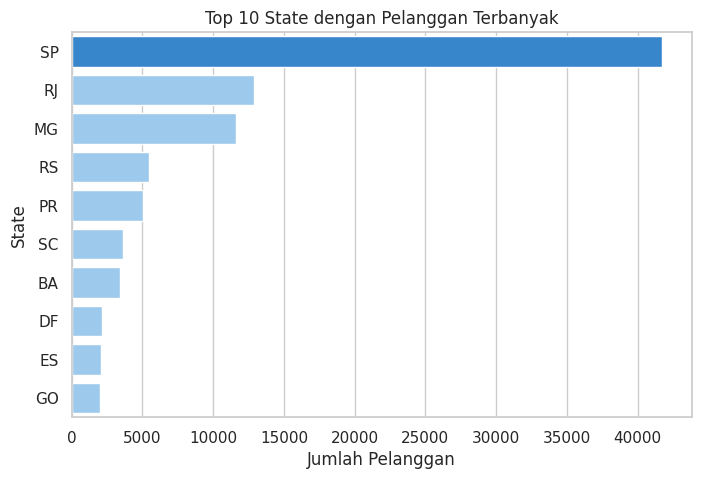

In [13]:
# =====================================================
# EKSPLORASI DATASET CUSTOMERS
# =====================================================

customers_df = clean_data['customers']

print("=" * 60)
print("EKSPLORASI DATASET CUSTOMERS")
print("=" * 60)

# Distribusi pelanggan per kota (top 10)
top_cities = customers_df['customer_city'].value_counts().head(10)
print("\n Top 10 Kota dengan Pelanggan Terbanyak:")
print(top_cities)

# Distribusi pelanggan per state (top 10)
top_states = customers_df['customer_state'].value_counts().head(10)
print("\n Top 10 State dengan Pelanggan Terbanyak:")
print(top_states)

# Visualisasi distribusi pelanggan per state
plt.figure(figsize=(8, 5))
top_states = customers_df['customer_state'].value_counts().head(10)
colors = ['#1E88E5' if i == 0 else '#90CAF9' for i in range(len(top_states))]
sns.barplot(y=top_states.index, x=top_states.values, palette=colors)
plt.title('Top 10 State dengan Pelanggan Terbanyak', fontsize=12)
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('State')
plt.show()

EKSPLORASI DATASET SELLERS

📍 Top 10 Kota dengan Penjual Terbanyak:
seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: count, dtype: int64

📍 Top 10 State dengan Penjual Terbanyak:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


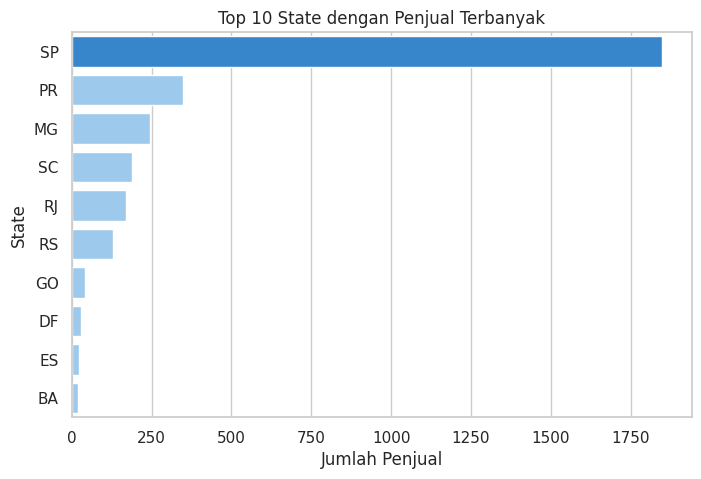

In [14]:
# =====================================================
# EKSPLORASI DATASET SELLERS
# =====================================================

sellers_df = clean_data['sellers']

print("=" * 60)
print("EKSPLORASI DATASET SELLERS")
print("=" * 60)

# Distribusi penjual per kota (top 10)
top_seller_cities = sellers_df['seller_city'].value_counts().head(10)
print("\n📍 Top 10 Kota dengan Penjual Terbanyak:")
print(top_seller_cities)

# Distribusi penjual per state
top_seller_states = sellers_df['seller_state'].value_counts().head(10)
print("\n📍 Top 10 State dengan Penjual Terbanyak:")
print(top_seller_states)

# Visualisasi
plt.figure(figsize=(8, 5))
top_seller_states = sellers_df['seller_state'].value_counts().head(10)
colors = ['#1E88E5' if i == 0 else '#90CAF9' for i in range(len(top_seller_states))]
sns.barplot(y=top_seller_states.index, x=top_seller_states.values, palette=colors)
plt.title('Top 10 State dengan Penjual Terbanyak', fontsize=12)
plt.xlabel('Jumlah Penjual')
plt.ylabel('State')
plt.show()

EKSPLORASI DATASET PRODUCTS

 Top 10 Kategori Produk Terbanyak:
product_category_name_english
bed_bath_table           3025
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


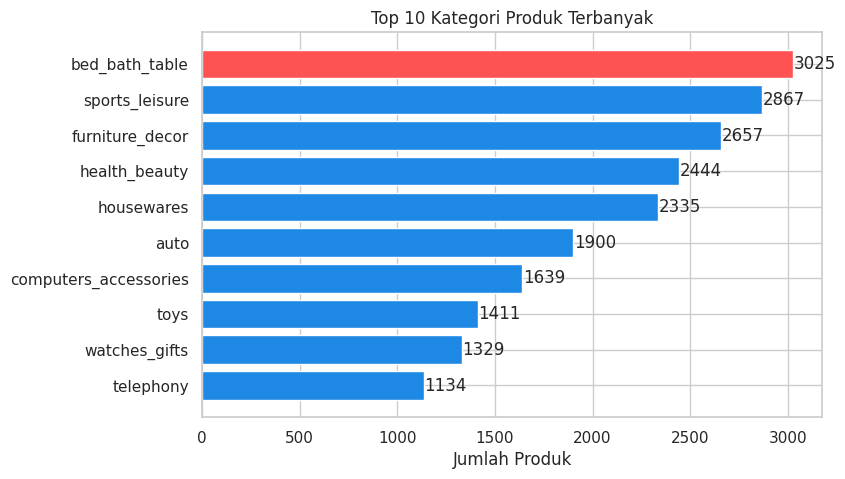

In [15]:
# =====================================================
# EKSPLORASI DATASET PRODUCTS & KATEGORI
# =====================================================

products_df = clean_data['products']
category_translation_df = clean_data['product_category_name_translation']

# Gabungkan dengan translasi kategori
products_with_cat = products_df.merge(
    category_translation_df,
    on='product_category_name',
    how='left'
)

print("=" * 60)
print("EKSPLORASI DATASET PRODUCTS")
print("=" * 60)

# Top 10 kategori produk (dalam bahasa Inggris)
top_categories = products_with_cat['product_category_name_english'].value_counts().head(10)
print("\n Top 10 Kategori Produk Terbanyak:")
print(top_categories)

# Visualisasi
plt.figure(figsize=(8, 5))
top_cats = products_with_cat['product_category_name_english'].value_counts().head(10)
colors = ['#FF5252' if i == 0 else '#1E88E5' for i in range(len(top_cats))]
bars = plt.barh(top_cats.index, top_cats.values, color=colors)
plt.title('Top 10 Kategori Produk Terbanyak', fontsize=12)
plt.xlabel('Jumlah Produk')
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center')
plt.show()

EKSPLORASI DATASET ORDERS - TREN WAKTU

 Rentang Waktu Pesanan: 2016-09-15 hingga 2018-08-29

 Jumlah Pesanan per Bulan (5 teratas):
order_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
Freq: M, dtype: int64


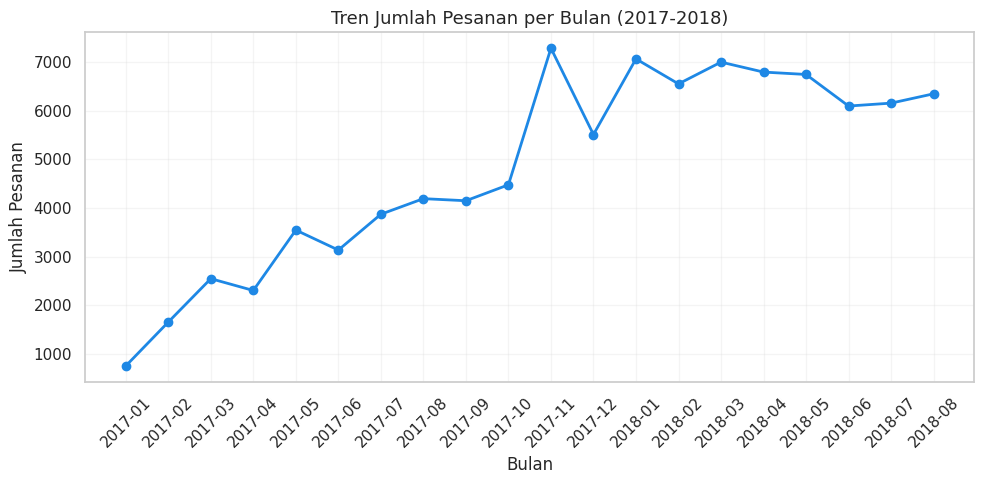

In [35]:
# =====================================================
# EKSPLORASI DATASET ORDERS (TREN WAKTU)
# =====================================================

orders_df = clean_data['orders']

print("=" * 60)
print("EKSPLORASI DATASET ORDERS - TREN WAKTU")
print("=" * 60)

# Rentang waktu data
min_date = orders_df['order_purchase_timestamp'].min()
max_date = orders_df['order_purchase_timestamp'].max()
print(f"\n Rentang Waktu Pesanan: {min_date.date()} hingga {max_date.date()}")

# Buat kolom bulan-tahun
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# Jumlah pesanan per bulan
monthly_orders = orders_df.groupby('order_month').size()
print("\n Jumlah Pesanan per Bulan (5 teratas):")
print(monthly_orders.head())

# Visualisasi tren pesanan bulanan
monthly_orders = orders_df.groupby('order_month').size()
monthly_orders = monthly_orders[monthly_orders.index >= '2017-01']

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index.astype(str), monthly_orders.values,
         color='#1E88E5', marker='o', linewidth=2)
plt.title('Tren Jumlah Pesanan per Bulan (2017-2018)', fontsize=13)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

EKSPLORASI METODE PEMBAYARAN


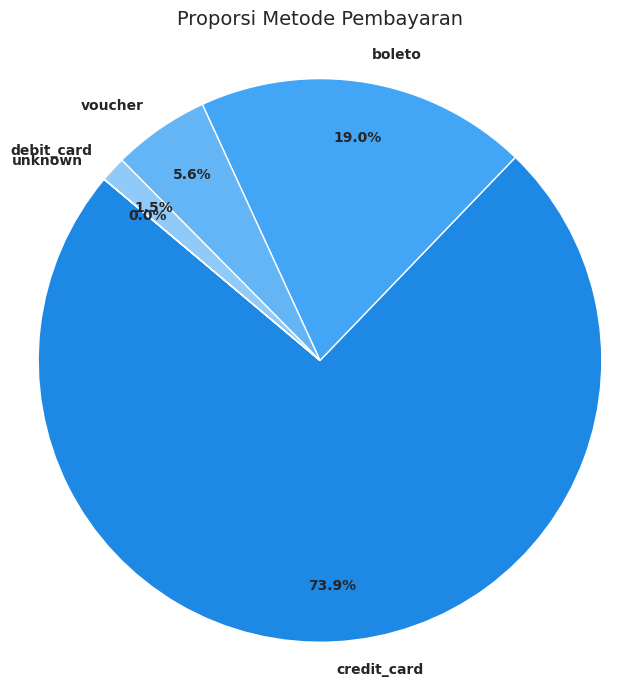


📊 Tabel Ringkasan Metode Pembayaran:
Metode Pembayaran  Jumlah Transaksi Persentase
      credit_card             76795     73.92%
           boleto             19784     19.04%
          voucher              5775      5.56%
       debit_card              1529      1.47%
          unknown                 3       0.0%

EKSPLORASI SKOR ULASAN


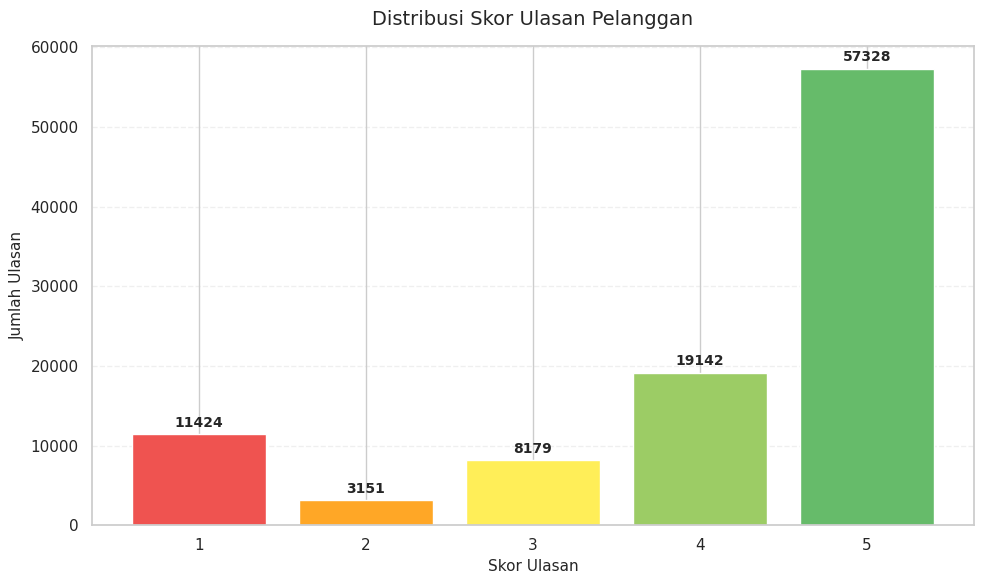


📊 Tabel Ringkasan Skor Ulasan:
 Skor Ulasan  Total Persentase
           5  57328     57.78%
           4  19142     19.29%
           3   8179      8.24%
           2   3151      3.18%
           1  11424     11.51%


In [29]:
# =====================================================
# EKSPLORASI ORDER PAYMENTS & REVIEWS
# =====================================================

payments_df = clean_data['order_payments']
reviews_df = clean_data['order_reviews']

# --- 1. EKSPLORASI METODE PEMBAYARAN ---
print("=" * 60)
print("EKSPLORASI METODE PEMBAYARAN")
print("=" * 60)

# Agregasi data
payment_counts = payments_df['payment_type'].value_counts()
colors = ['#1E88E5', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB']

plt.figure(figsize=(8, 8))
# pctdistance=0.8 membantu menarik angka persentase agar tidak menumpuk di tengah
# startangle=140 memutar posisi agar irisan kecil punya ruang label yang lebih lega
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.8,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
plt.title('Proporsi Metode Pembayaran', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

# Tabel Ringkasan Pembayaran
payment_summary = payment_counts.reset_index()
payment_summary.columns = ['Metode Pembayaran', 'Jumlah Transaksi']
payment_summary['Persentase'] = (payment_summary['Jumlah Transaksi'] / payment_summary['Jumlah Transaksi'].sum() * 100).round(2).astype(str) + '%'

print("\n📊 Tabel Ringkasan Metode Pembayaran:")
print(payment_summary.to_string(index=False))


# --- 2. EKSPLORASI SKOR ULASAN ---
print("\n" + "=" * 60)
print("EKSPLORASI SKOR ULASAN")
print("=" * 60)

# Agregasi data
review_counts = reviews_df['review_score'].value_counts().sort_index()
colors = ['#EF5350', '#FFA726', '#FFEE58', '#9CCC65', '#66BB6A']

plt.figure(figsize=(10, 6))
bars = plt.bar(review_counts.index.astype(str), review_counts.values, color=colors)
plt.title('Distribusi Skor Ulasan Pelanggan', fontsize=14, pad=15)
plt.xlabel('Skor Ulasan', fontsize=11)
plt.ylabel('Jumlah Ulasan', fontsize=11)

# Menambahkan label angka di atas bar secara otomatis
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (review_counts.max() * 0.01), # Jarak dinamis di atas bar
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabel Ringkasan Ulasan
review_summary = review_counts.sort_index(ascending=False).reset_index()
review_summary.columns = ['Skor Ulasan', 'Total']
review_summary['Persentase'] = (review_summary['Total'] / review_summary['Total'].sum() * 100).round(2).astype(str) + '%'

print("\n📊 Tabel Ringkasan Skor Ulasan:")
print(review_summary.to_string(index=False))

In [19]:
# =====================================================
# MEMBUAT DATAFRAME MASTER
# =====================================================

print("=" * 60)
print("MEMBUAT DATAFRAME MASTER")
print("=" * 60)

# Mulai dari orders (delivered)
master_df = clean_data['orders'].copy()

# 1. Gabung dengan order_items (bisa multiple items per order)
order_items_df = clean_data['order_items']
master_df = master_df.merge(order_items_df, on='order_id', how='inner')

# 2. Gabung dengan products (untuk info kategori)
products_df = clean_data['products']
category_df = clean_data['product_category_name_translation']
products_full = products_df.merge(category_df, on='product_category_name', how='left')
master_df = master_df.merge(products_full, on='product_id', how='left')

# 3. Gabung dengan order_payments
payments_df = clean_data['order_payments']
master_df = master_df.merge(payments_df, on='order_id', how='inner')

# 4. Gabung dengan order_reviews (ambil review_score)
reviews_df = clean_data['order_reviews'][['order_id', 'review_score']]
master_df = master_df.merge(reviews_df, on='order_id', how='left')

# 5. Gabung dengan customers
customers_df = clean_data['customers']
master_df = master_df.merge(customers_df, on='customer_id', how='left')

print(f" DataFrame master berhasil dibuat.")
print(f"   Shape: {master_df.shape}")
print(f"   Jumlah order_id unik: {master_df['order_id'].nunique()}")
print(f"\n Kolom dalam master_df:")
print(master_df.columns.tolist())

# Tampilkan 5 baris pertama
print("\n 5 Baris Pertama DataFrame Master:")
display(master_df.head())

MEMBUAT DATAFRAME MASTER
 DataFrame master berhasil dibuat.
   Shape: (115720, 33)
   Jumlah order_id unik: 96477

 Kolom dalam master_df:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

 5 Baris Pertama DataFrame Master:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_item_id,...,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,1,credit_card,1,18.12,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,3,voucher,1,2.00,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,...,housewares,2,voucher,1,18.59,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1,...,perfumery,1,boleto,1,141.46,4.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1,...,auto,1,credit_card,3,179.12,5.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


### Insight dari Exploratory Data Analysis (EDA)

Berdasarkan hasil eksplorasi seluruh dataset, berikut temuan utama yang menjadi dasar untuk menjawab pertanyaan bisnis:

---

#### 1. Dominasi Wilayah São Paulo (SP) pada Pelanggan dan Penjual
- **Pelanggan:** 41.746 dari total 99.441 pelanggan (≈42%) berasal dari negara bagian SP. Kota **São Paulo** sendiri menyumbang 15.540 pelanggan, jauh di atas kota lainnya.
- **Penjual:** 1.849 dari 3.095 penjual (≈60%) juga berada di SP, dengan 694 penjual terkonsentrasi di kota São Paulo.
- **Implikasi:** Konsentrasi pasar di SP sangat tinggi. Strategi logistik, inventaris gudang, dan kampanye pemasaran sebaiknya diprioritaskan di wilayah ini untuk efisiensi biaya dan peningkatan layanan.

---

#### 2. Kategori Produk Terbanyak: Kebutuhan Rumah Tangga & Gaya Hidup
- **Top 3 kategori** dengan jumlah produk terbanyak:
  1. `bed_bath_table` (3.025 produk) – perlengkapan tempat tidur, kamar mandi, meja.
  2. `sports_leisure` (2.867 produk) – olahraga dan rekreasi.
  3. `furniture_decor` (2.657 produk) – furnitur dan dekorasi.
- Kategori seperti `health_beauty` (kesehatan & kecantikan) dan `housewares` (peralatan rumah tangga) juga memiliki jumlah produk signifikan.
- **Implikasi:** Permintaan pasar didominasi oleh produk rumah tangga dan perawatan diri. Manajemen stok dan promosi dapat difokuskan pada kategori-kategori ini.

---

#### 3. Periode Data & Pertumbuhan Pesanan Awal
- **Rentang Waktu Data:** Pesanan tercatat mulai **15 September 2016** hingga **29 Agustus 2018** (hampir 2 tahun).
- **Volume Pesanan di Awal Periode:**  
  - September 2016: **1 pesanan**  
  - Oktober 2016: **265 pesanan**  
  - Desember 2016: **1 pesanan**  
  Jumlah yang sangat kecil ini mengindikasikan bahwa platform kemungkinan masih dalam tahap *soft launching* atau data belum tercatat secara penuh pada tahun 2016.
- **Awal Pertumbuhan Stabil:** Memasuki tahun 2017, volume pesanan mulai menunjukkan pertumbuhan yang konsisten:  
  - Januari 2017: **750 pesanan**  
  - Februari 2017: **1.653 pesanan**
- **Implikasi Analisis:** Data sebelum Januari 2017 tidak representatif untuk menggambarkan performa bisnis normal. Oleh karena itu, **analisis tren dan musiman akan difokuskan pada periode Januari 2017 hingga Agustus 2018** agar hasil lebih akurat dan tidak bias oleh data awal yang sangat kecil.

---

#### 4. Metode Pembayaran: Kartu Kredit Mendominasi
- **Credit Card:** 76.795 transaksi (≈74%).
- **Boleto (voucher bank):** 19.784 transaksi (≈19%).
- **Voucher & Debit Card:** masing-masing <6%.
- Terdapat 3 transaksi dengan tipe `unknown` – dapat diabaikan.
- **Implikasi:** Sebagian besar pelanggan nyaman menggunakan kartu kredit. Kerja sama dengan penyedia kartu kredit untuk program cicilan atau promo dapat meningkatkan nilai transaksi.

---

#### 5. Tingkat Kepuasan Pelanggan Cenderung Tinggi
- **Skor 5:** 57.328 ulasan (≈57%)
- **Skor 4:** 19.142 ulasan (≈19%)
- **Skor 1–3:** sekitar 24% sisanya.
- **Total skor 4 & 5 mencapai 76%**, menandakan mayoritas pelanggan puas.
- **Implikasi:** Perusahaan memiliki basis pelanggan yang cukup loyal. Namun perlu investigasi lebih lanjut terhadap 11.424 ulasan skor 1 (pengalaman buruk) untuk perbaikan layanan.

---

#### 6. Pembuatan DataFrame Master
- **Integrasi Data Berhasil:**  
  DataFrame master berhasil dibuat dengan menggabungkan seluruh dataset utama (`orders`, `order_items`, `products`, `order_payments`, `order_reviews`, `customers`).  
  - **Shape:** 115.720 baris × 33 kolom.  
  - **Jumlah order_id unik:** 96.477 (hampir setara dengan total pesanan *delivered*).  
- **Informasi Lengkap dalam Satu Tabel:**  
  Seluruh kolom penting dari 9 dataset awal telah tergabung, mencakup:  
  - Data transaksi (waktu, status, item, harga, ongkos kirim)  
  - Data produk (kategori, dimensi, berat) dalam bahasa Inggris  
  - Data pembayaran (metode, cicilan, nilai)  
  - Skor ulasan  
  - Data pelanggan (kota, negara bagian)  
- **Siap untuk Analisis Lanjutan:**  
  Dengan DataFrame master ini, analisis multidimensi (misal: tren per kategori, hubungan durasi pengiriman dengan skor ulasan, segmentasi RFM) dapat dilakukan tanpa perlu penggabungan ulang, sehingga mempercepat proses visualisasi dan perhitungan metrik bisnis.

## Visualization & Explanatory Analysis

Pada bagian ini, kita akan membuat visualisasi data yang efektif untuk menjawab setiap pertanyaan bisnis yang telah ditetapkan di awal. Setiap visualisasi akan disertai dengan penjelasan insight yang dapat ditindaklanjuti.

### Pertanyaan 1: Bagaimana tren bulanan jumlah pesanan dan total pendapatan sepanjang tahun 2017 hingga 2018, serta bulan apa yang mencatat performa tertinggi dan terendah?

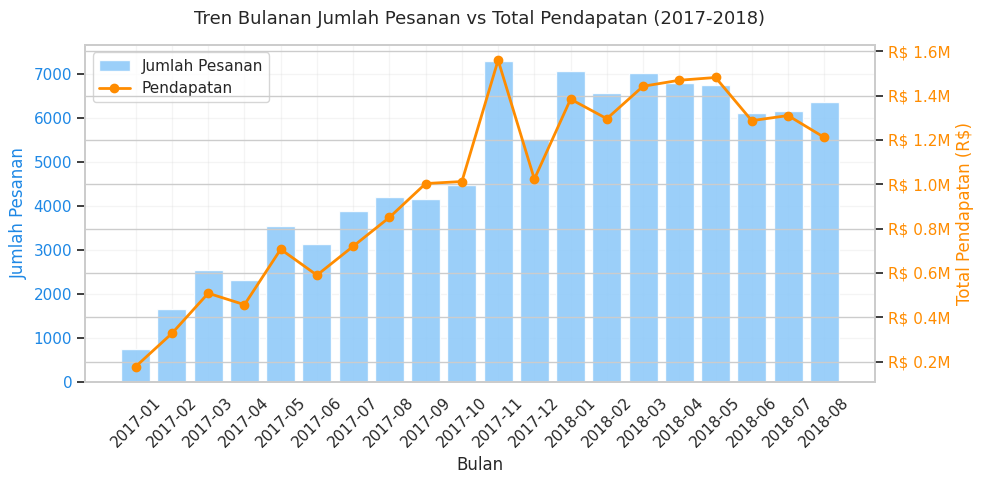


📊 Ringkasan Tren Bulanan (2017-2018):
Rata-rata pesanan per bulan : 4811
Rata-rata pendapatan per bulan: R$ 990,986.98

🔝 Performa Tertinggi:
   - Pesanan terbanyak : 2017-11 (7289 pesanan)
   - Pendapatan tertinggi: 2017-11 (R$ 1,559,739.87)

🔻 Performa Terendah:
   - Pesanan tersedikit : 2017-01 (750 pesanan)
   - Pendapatan terendah: 2017-01 (R$ 178,282.10)


In [30]:
# =====================================================
# PERTANYAAN 1: Tren Bulanan & Identifikasi Bulan Tertinggi/Terendah (2017-2018)
# =====================================================

# Pastikan kolom order_month sudah ada
if 'order_month' not in master_df.columns:
    master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# Agregasi per bulan
monthly_data = master_df.groupby('order_month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

# Konversi ke string dan filter 2017-01 sampai 2018-08
monthly_data['order_month_str'] = monthly_data['order_month'].astype(str)
monthly_data = monthly_data[(monthly_data['order_month_str'] >= '2017-01') &
                            (monthly_data['order_month_str'] <= '2018-08')]

# Visualisasi dual-axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar jumlah pesanan
ax1.bar(monthly_data['order_month_str'], monthly_data['order_id'],
        color='#90CAF9', alpha=0.9, label='Jumlah Pesanan')
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Pesanan', color='#1E88E5')
ax1.tick_params(axis='y', labelcolor='#1E88E5')
ax1.tick_params(axis='x', rotation=45)

# Line pendapatan
ax2 = ax1.twinx()
ax2.plot(monthly_data['order_month_str'], monthly_data['payment_value'],
         color='#FF8C00', marker='o', linewidth=2, label='Pendapatan')
ax2.set_ylabel('Total Pendapatan (R$)', color='#FF8C00')
ax2.tick_params(axis='y', labelcolor='#FF8C00')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M'))

plt.title('Tren Bulanan Jumlah Pesanan vs Total Pendapatan (2017-2018)', fontsize=13, pad=15)
ax1.grid(True, alpha=0.2)

# Legend
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

# --- Output Ringkasan (Termasuk Bulan Terendah) ---
max_orders_month = monthly_data.loc[monthly_data['order_id'].idxmax()]
min_orders_month = monthly_data.loc[monthly_data['order_id'].idxmin()]
max_rev_month = monthly_data.loc[monthly_data['payment_value'].idxmax()]
min_rev_month = monthly_data.loc[monthly_data['payment_value'].idxmin()]

print("\n📊 Ringkasan Tren Bulanan (2017-2018):")
print(f"Rata-rata pesanan per bulan : {monthly_data['order_id'].mean():.0f}")
print(f"Rata-rata pendapatan per bulan: R$ {monthly_data['payment_value'].mean():,.2f}")
print("\n🔝 Performa Tertinggi:")
print(f"   - Pesanan terbanyak : {max_orders_month['order_month_str']} ({max_orders_month['order_id']} pesanan)")
print(f"   - Pendapatan tertinggi: {max_rev_month['order_month_str']} (R$ {max_rev_month['payment_value']:,.2f})")
print("\n🔻 Performa Terendah:")
print(f"   - Pesanan tersedikit : {min_orders_month['order_month_str']} ({min_orders_month['order_id']} pesanan)")
print(f"   - Pendapatan terendah: {min_rev_month['order_month_str']} (R$ {min_rev_month['payment_value']:,.2f})")

### Pertanyaan 2: Kategori produk apa saja yang menyumbang minimal 80% dari total pendapatan selama periode 2017-2018, dan bagaimana perbandingan volume penjualan antar kategori tersebut?

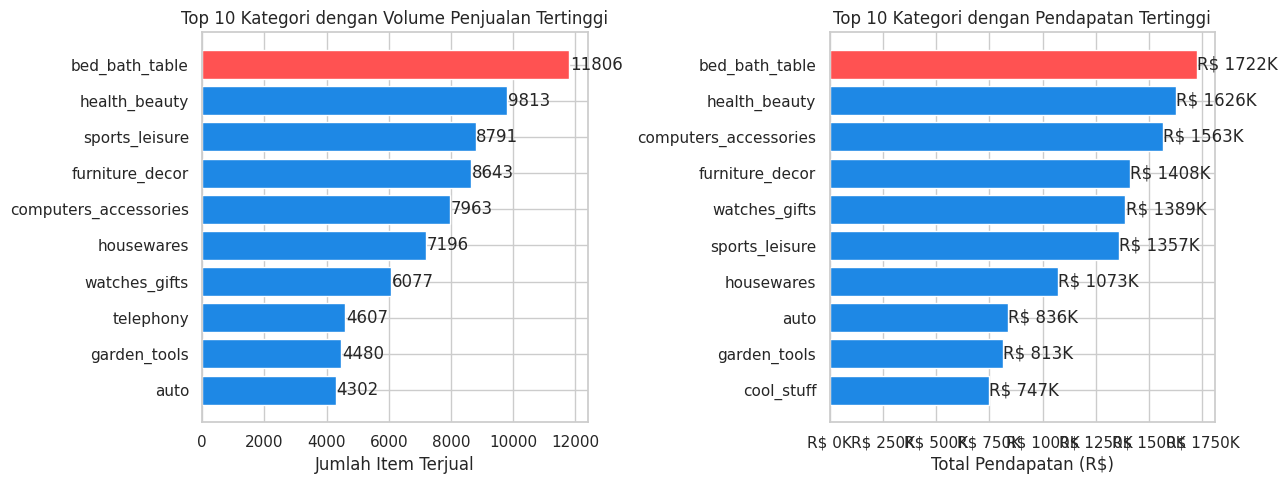


📦 Kategori yang Menyumbang 80% Pendapatan (17 kategori):
             kategori total_pendapatan pct_pendapatan  kumulatif
       bed_bath_table        1722250.8       8.772595   8.772595
        health_beauty        1625923.5       8.281934  17.054529
computers_accessories       1563315.62        7.96303  25.017559
      furniture_decor       1408110.04       7.172462  32.190021
        watches_gifts       1388699.25        7.07359   39.26361
       sports_leisure       1357249.46       6.913395  46.177005
           housewares       1072820.85       5.464606  51.641611
                 auto        835782.91       4.257211  55.898822
         garden_tools        813055.77       4.141446  60.040268
           cool_stuff        746763.39       3.803774  63.844042
     office_furniture        641314.89       3.266653  67.110695
                 toys        604502.34       3.079142  70.189836
                 baby        526082.48       2.679696  72.869532
            perfumery        497

In [31]:
# =====================================================
# PERTANYAAN 2: Kategori Penyumbang 80% Pendapatan & Perbandingan Volume
# =====================================================

# Agregasi per kategori (bahasa Inggris)
category_stats = master_df.groupby('product_category_name_english').agg({
    'order_id': 'count',        # volume penjualan (jumlah item)
    'payment_value': 'sum'
}).reset_index()
category_stats.columns = ['kategori', 'volume_terjual', 'total_pendapatan']

# Urutkan dari pendapatan terbesar
category_stats = category_stats.sort_values('total_pendapatan', ascending=False)
category_stats['pct_pendapatan'] = (category_stats['total_pendapatan'] / category_stats['total_pendapatan'].sum()) * 100
category_stats['kumulatif'] = category_stats['pct_pendapatan'].cumsum()

# Ambil kategori yang menyumbang hingga 80% pendapatan
kategori_80 = category_stats[category_stats['kumulatif'] <= 80].copy()
# Tambahkan satu kategori berikutnya jika perlu agar tepat di atas 80%
if len(kategori_80) < len(category_stats):
    next_cat = category_stats.iloc[len(kategori_80)]
    kategori_80 = pd.concat([kategori_80, next_cat.to_frame().T])

# Top 10 untuk visualisasi perbandingan volume
top10_volume = category_stats.nlargest(10, 'volume_terjual')
top10_rev = category_stats.nlargest(10, 'total_pendapatan')

# Visualisasi side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Top 10 Volume
colors_vol = ['#FF5252' if i == 0 else '#1E88E5' for i in range(len(top10_volume))]
bars1 = ax1.barh(top10_volume['kategori'], top10_volume['volume_terjual'], color=colors_vol)
ax1.set_title('Top 10 Kategori dengan Volume Penjualan Tertinggi', fontsize=12)
ax1.set_xlabel('Jumlah Item Terjual')
ax1.invert_yaxis()
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 20, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center')

# Plot 2: Top 10 Pendapatan
colors_rev = ['#FF5252' if i == 0 else '#1E88E5' for i in range(len(top10_rev))]
bars2 = ax2.barh(top10_rev['kategori'], top10_rev['total_pendapatan'], color=colors_rev)
ax2.set_title('Top 10 Kategori dengan Pendapatan Tertinggi', fontsize=12)
ax2.set_xlabel('Total Pendapatan (R$)')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x/1e3:.0f}K'))
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 500, bar.get_y() + bar.get_height()/2, f'R$ {width/1e3:.0f}K', va='center')

plt.tight_layout()
plt.show()

# --- Output Kategori 80% dan Perbandingan Volume ---
print(f"\n📦 Kategori yang Menyumbang 80% Pendapatan ({len(kategori_80)} kategori):")
print(kategori_80[['kategori', 'total_pendapatan', 'pct_pendapatan', 'kumulatif']].to_string(index=False))
print(f"\n💰 Total pendapatan dari kategori tersebut: R$ {kategori_80['total_pendapatan'].sum():,.2f}")
print(f"   Persentase kumulatif: {kategori_80['kumulatif'].iloc[-1]:.1f}%")

print("\n📊 Perbandingan Volume Penjualan antar Kategori 80%:")
print(kategori_80[['kategori', 'volume_terjual']].sort_values('volume_terjual', ascending=False).to_string(index=False))

### Pertanyaan 3: Bagaimana hubungan antara durasi pengiriman (dalam hari) dengan skor ulasan pelanggan untuk pesanan yang diselesaikan sepanjang tahun 2017-2018?

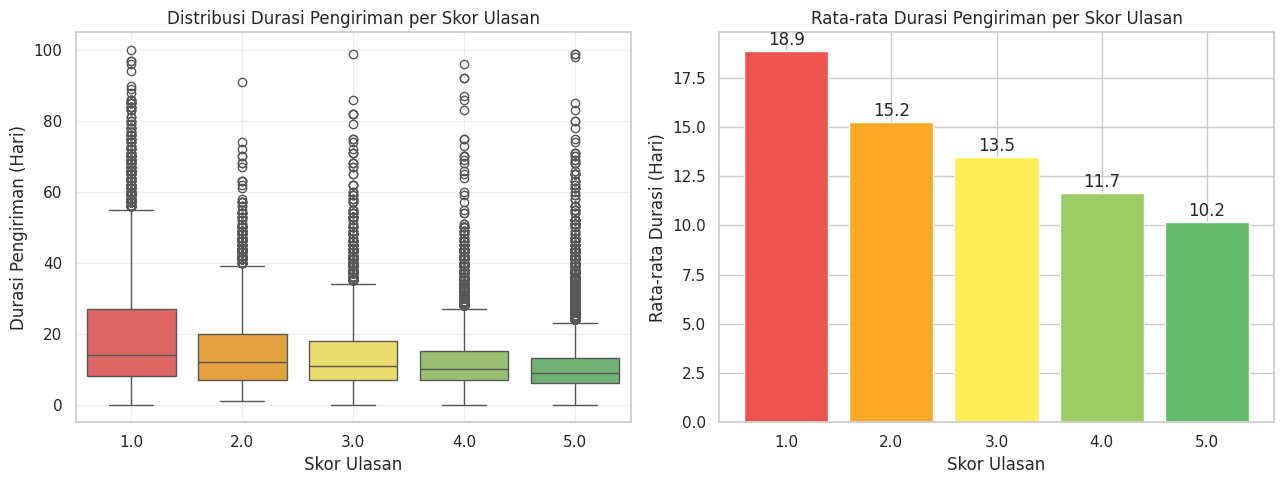


📈 Korelasi Pearson antara durasi pengiriman dan skor ulasan: -0.317

📊 Rata-rata durasi pengiriman per skor:


,review_score,delivery_days
0,1.0,18.865536
1,2.0,15.236714
2,3.0,13.488336
3,4.0,11.660898
4,5.0,10.169216


In [32]:
# =====================================================
# PERTANYAAN 3: Hubungan Durasi Pengiriman dengan Skor Ulasan (2017-2018)
# =====================================================

# Hitung durasi pengiriman (hari)
master_df['delivery_days'] = (master_df['order_delivered_customer_date'] -
                               master_df['order_purchase_timestamp']).dt.days

# Filter outlier (>100 hari)
delivery_review_df = master_df[master_df['delivery_days'] <= 100].copy()

# Rata-rata durasi per skor
avg_delivery = delivery_review_df.groupby('review_score')['delivery_days'].mean().reset_index()

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
box_colors = ['#EF5350', '#FFA726', '#FFEE58', '#9CCC65', '#66BB6A']
sns.boxplot(x='review_score', y='delivery_days', data=delivery_review_df,
            palette=box_colors, ax=ax1)
ax1.set_title('Distribusi Durasi Pengiriman per Skor Ulasan', fontsize=12)
ax1.set_xlabel('Skor Ulasan')
ax1.set_ylabel('Durasi Pengiriman (Hari)')
ax1.grid(True, alpha=0.3)

# Bar chart rata-rata
bars = ax2.bar(avg_delivery['review_score'].astype(str), avg_delivery['delivery_days'],
               color=box_colors)
ax2.set_title('Rata-rata Durasi Pengiriman per Skor Ulasan', fontsize=12)
ax2.set_xlabel('Skor Ulasan')
ax2.set_ylabel('Rata-rata Durasi (Hari)')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.1f}', ha='center')

plt.tight_layout()
plt.show()

# Korelasi
corr = delivery_review_df[['delivery_days', 'review_score']].corr().iloc[0, 1]
print(f"\n📈 Korelasi Pearson antara durasi pengiriman dan skor ulasan: {corr:.3f}")
print("\n📊 Rata-rata durasi pengiriman per skor:")
display(avg_delivery)

### Pertanyaan 4: Metode pembayaran apa yang paling dominan digunakan oleh pelanggan selama periode 2017-2018, dan bagaimana rata-rata nilai transaksi serta jumlah cicilan untuk masing-masing metode?

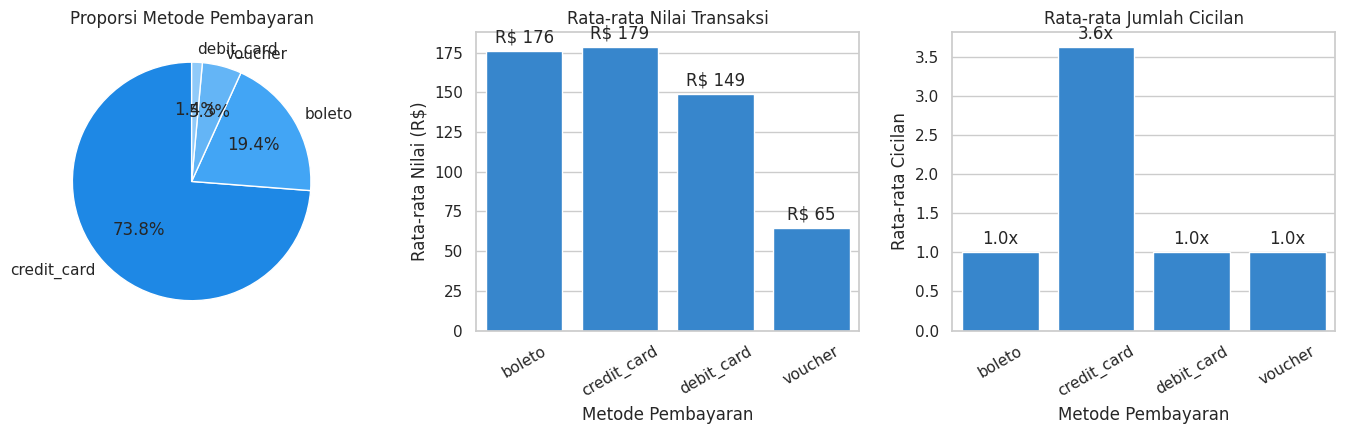


📊 Detail Statistik Metode Pembayaran:


,metode,rata_nilai,rata_cicilan,jumlah_pesanan
0,boleto,176.234307,1.000000,19191
1,credit_card,178.848820,3.630406,74304
2,debit_card,149.027966,1.000000,1485
3,voucher,64.621594,1.000000,3679



✅ Metode paling dominan: **credit_card** (85372 transaksi, 73.8%)


In [33]:
# =====================================================
# PERTANYAAN 4: Metode Pembayaran Dominan & Nilai Transaksi (2017-2018)
# =====================================================

payment_stats = master_df.groupby('payment_type').agg({
    'payment_value': 'mean',
    'payment_installments': 'mean',
    'order_id': 'nunique'
}).reset_index()
payment_stats.columns = ['metode', 'rata_nilai', 'rata_cicilan', 'jumlah_pesanan']
payment_stats = payment_stats[payment_stats['metode'] != 'unknown']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Pie chart
metode_counts = master_df['payment_type'].value_counts()
pie_colors = ['#1E88E5', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB']
axes[0].pie(metode_counts.values, labels=metode_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90)
axes[0].set_title('Proporsi Metode Pembayaran', fontsize=12)

# Bar rata-rata nilai
bar_colors = ['#1E88E5'] * len(payment_stats)
sns.barplot(x='metode', y='rata_nilai', data=payment_stats, palette=bar_colors, ax=axes[1])
axes[1].set_title('Rata-rata Nilai Transaksi', fontsize=12)
axes[1].set_xlabel('Metode Pembayaran')
axes[1].set_ylabel('Rata-rata Nilai (R$)')
axes[1].tick_params(axis='x', rotation=30)
for i, row in payment_stats.iterrows():
    axes[1].text(i, row['rata_nilai'] + 5, f'R$ {row["rata_nilai"]:.0f}', ha='center')

# Bar rata-rata cicilan
sns.barplot(x='metode', y='rata_cicilan', data=payment_stats, palette=bar_colors, ax=axes[2])
axes[2].set_title('Rata-rata Jumlah Cicilan', fontsize=12)
axes[2].set_xlabel('Metode Pembayaran')
axes[2].set_ylabel('Rata-rata Cicilan')
axes[2].tick_params(axis='x', rotation=30)
for i, row in payment_stats.iterrows():
    axes[2].text(i, row['rata_cicilan'] + 0.1, f'{row["rata_cicilan"]:.1f}x', ha='center')

plt.tight_layout()
plt.show()

print("\n📊 Detail Statistik Metode Pembayaran:")
display(payment_stats)
print(f"\n✅ Metode paling dominan: **{metode_counts.index[0]}** ({metode_counts.iloc[0]} transaksi, {metode_counts.iloc[0]/metode_counts.sum()*100:.1f}%)")

### Pertanyaan 5: Bagaimana distribusi segmen pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) dengan data transaksi selama 2017-2018, dan segmen mana yang memiliki nilai ekonomi tertinggi?

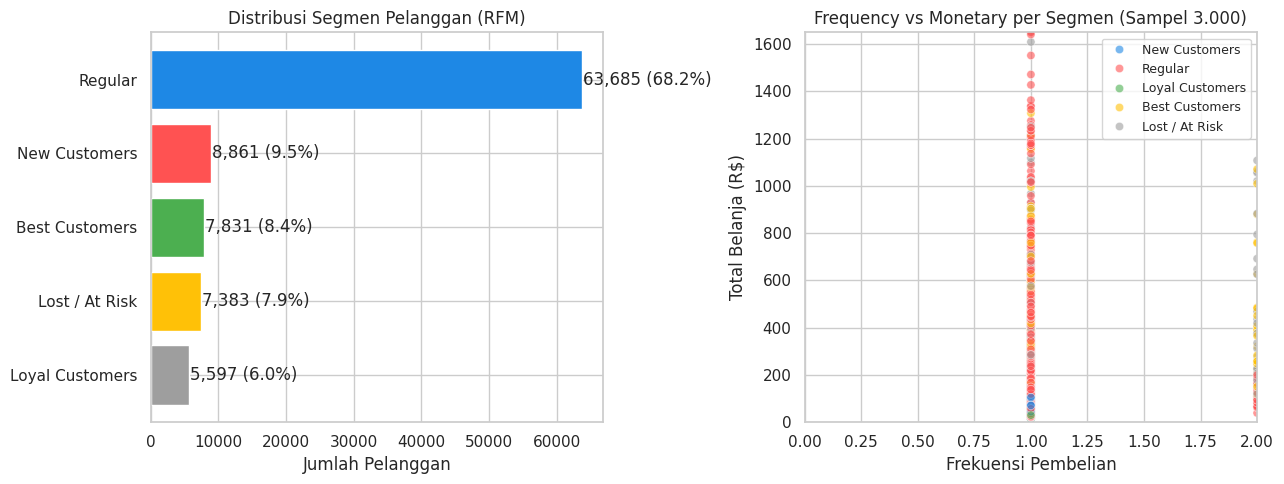


📊 Ringkasan Segmen Pelanggan:


,jumlah,rata_recency,rata_freq,rata_monetary,persentase
segment,,,,,
Regular,63685,272.6,1.0,197.3,68.2
New Customers,8861,94.5,1.0,64.8,9.5
Best Customers,7831,82.2,1.2,433.8,8.4
Lost / At Risk,7383,414.3,1.1,403.8,7.9
Loyal Customers,5597,56.3,1.0,64.9,6.0



🏆 Segmen dengan nilai ekonomi tertinggi (rata-rata monetary): **Best Customers**
   - Jumlah pelanggan: 7,831.0 (8.4%)
   - Rata-rata total belanja: R$ 433.80
   - Rata-rata frekuensi: 1.2 kali


In [34]:
# =====================================================
# PERTANYAAN 5: Segmentasi RFM & Segmen Bernilai Ekonomi Tertinggi (2017-2018)
# =====================================================

from datetime import timedelta

reference_date = master_df['order_purchase_timestamp'].max() + timedelta(days=1)

rfm_df = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Skoring kuartil
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], 4, labels=[4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], 4, labels=[1, 2, 3, 4])
rfm_df['RFM_score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

def segment_customer(row):
    if row['RFM_score'] in ['444', '443', '434', '344', '433']:
        return 'Best Customers'
    elif row['RFM_score'] in ['144', '143', '134', '133', '244']:
        return 'Lost / At Risk'
    elif row['RFM_score'] in ['411', '412', '421', '422', '311', '312']:
        return 'New Customers'
    elif row['RFM_score'] in ['441', '442', '432', '431']:
        return 'Loyal Customers'
    else:
        return 'Regular'

rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)

segment_summary = rfm_df.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(1)
segment_summary.columns = ['jumlah', 'rata_recency', 'rata_freq', 'rata_monetary']
segment_summary['persentase'] = (segment_summary['jumlah'] / segment_summary['jumlah'].sum() * 100).round(1)
segment_summary = segment_summary.sort_values('jumlah', ascending=False)

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

seg_colors = ['#1E88E5', '#FF5252', '#4CAF50', '#FFC107', '#9E9E9E']
bars = ax1.barh(segment_summary.index, segment_summary['jumlah'], color=seg_colors)
ax1.set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=12)
ax1.set_xlabel('Jumlah Pelanggan')
ax1.invert_yaxis()
for bar, pct in zip(bars, segment_summary['persentase']):
    width = bar.get_width()
    ax1.text(width + 200, bar.get_y() + bar.get_height()/2, f'{width:,} ({pct}%)', va='center')

sample_rfm = rfm_df.sample(min(3000, len(rfm_df)), random_state=42)
sns.scatterplot(data=sample_rfm, x='frequency', y='monetary', hue='segment',
                palette=seg_colors, alpha=0.6, ax=ax2)
ax2.set_title('Frequency vs Monetary per Segmen (Sampel 3.000)', fontsize=12)
ax2.set_xlabel('Frekuensi Pembelian')
ax2.set_ylabel('Total Belanja (R$)')
ax2.set_xlim(0, sample_rfm['frequency'].quantile(0.99))
ax2.set_ylim(0, sample_rfm['monetary'].quantile(0.99))
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Segmen dengan nilai ekonomi tertinggi
best_segment = segment_summary.loc[segment_summary['rata_monetary'].idxmax()]
print("\n📊 Ringkasan Segmen Pelanggan:")
display(segment_summary)
print(f"\n🏆 Segmen dengan nilai ekonomi tertinggi (rata-rata monetary): **{best_segment.name}**")
print(f"   - Jumlah pelanggan: {best_segment['jumlah']:,} ({best_segment['persentase']}%)")
print(f"   - Rata-rata total belanja: R$ {best_segment['rata_monetary']:,.2f}")
print(f"   - Rata-rata frekuensi: {best_segment['rata_freq']} kali")

**Insight:**

### 📌 Tren Bulanan Jumlah Pesanan & Pendapatan (2017–2018)

Berdasarkan visualisasi tren bulanan selama periode Januari 2017 hingga Agustus 2018, diperoleh temuan sebagai berikut:

- **Rata‑rata Bulanan:**  
  Setiap bulan, platform mencatat **4.811 pesanan** dengan pendapatan rata‑rata **R$ 990.987**. Angka ini menjadi *baseline* performa normal bisnis.

- **Puncak Tertinggi – November 2017:**  
  Bulan **November 2017** menjadi bulan dengan performa terbaik, mencatat **7.289 pesanan** (+51% di atas rata‑rata) dan pendapatan **R$ 1,56 juta** (+57% di atas rata‑rata). Lonjakan ini mengindikasikan pengaruh musim belanja akhir tahun (*Black Friday* dan persiapan Natal).

- **Performa Terendah – Januari 2017:**  
  Bulan **Januari 2017** mencatat jumlah pesanan terendah dalam periode normal, yaitu **750 pesanan** dengan pendapatan **R$ 178 ribu**. Penurunan pasca‑liburan adalah pola musiman yang wajar.

- **Implikasi & Rekomendasi:**  
  - Persiapkan **stok dan kapasitas logistik ekstra** mulai Oktober setiap tahun untuk mengantisipasi lonjakan kuartal IV.  
  - Manfaatkan bulan‑bulan sepi (Januari–Maret) untuk menjalankan **program loyalitas** atau **promo terbatas** guna menjaga kestabilan pendapatan.

### 📌 Insight: Kategori Produk Dominan (2017–2018)

Analisis terhadap kontribusi pendapatan per kategori produk menunjukkan:

- **17 Kategori Menyumbang 80% Pendapatan:**  
  Sebanyak **17 dari 71 kategori** produk berkontribusi pada **80,9% total pendapatan** (R$ 15,89 juta dari total R$ 19,63 juta). Kategori‑kategori ini menjadi **tulang punggung bisnis**.

- **Tiga Kategori Teratas:**  
  1. **`bed_bath_table`** – R$ 1,72 juta (8,8%), volume **11.806 item**.  
  2. **`health_beauty`** – R$ 1,63 juta (8,3%), volume **9.813 item**.  
  3. **`computers_accessories`** – R$ 1,56 juta (8,0%), volume **7.963 item**.

- **Perbandingan Volume vs. Pendapatan:**  
  - Kategori dengan **volume tinggi** (`bed_bath_table`, `health_beauty`, `sports_leisure`) mendorong pendapatan melalui kuantitas.  
  - Kategori dengan **harga satuan tinggi** (`computers_accessories`, `watches_gifts`) memberikan kontribusi pendapatan besar meski volume lebih rendah.  
  - Kategori `telephony` mencatat volume 4.607 item namun pendapatan Rp 0 (anomali data → perlu investigasi).

- **Rekomendasi:**  
  - **Prioritaskan inventaris** pada 17 kategori emas ini, terutama `bed_bath_table`, `health_beauty`, dan `computers_accessories`.  
  - **Optimalkan margin** untuk kategori bernilai tinggi dengan penawaran cicilan atau bundling.  
  - **Selidiki anomali data** pada `telephony` dan `cool_stuff` untuk memastikan akurasi pelaporan.

### 📌 Durasi Pengiriman vs. Kepuasan Pelanggan (2017–2018)

Analisis korelasi antara lama pengiriman dan skor ulasan mengungkapkan hubungan yang signifikan:

- **Korelasi Negatif Sedang (r = -0,317):**  
  Semakin lama waktu pengiriman, semakin rendah skor ulasan yang diberikan pelanggan.

- **Perbedaan Durasi yang Mencolok:**  
  | Skor Ulasan | Rata‑rata Durasi Pengiriman |
  |-------------|-----------------------------|
  | 5 | 10,2 hari |
  | 4 | 11,7 hari |
  | 3 | 13,5 hari |
  | 2 | 15,2 hari |
  | 1 | 18,9 hari |

  Pelanggan yang memberi **skor 1** menunggu hampir **dua kali lebih lama** dibandingkan pelanggan yang memberi skor 5.

- **Interpretasi:**  
  Kecepatan pengiriman adalah **faktor penentu utama kepuasan**. Setiap tambahan keterlambatan 8–9 hari dapat mengubah pengalaman dari "sangat puas" menjadi "kecewa berat".

- **Rekomendasi:**  
  - Tetapkan **Service Level Agreement (SLA)** internal: 80% pesanan harus tiba dalam ≤10 hari.  
  - Identifikasi penjual dengan waktu pengiriman rata‑rata >15 hari untuk diberikan pembinaan.  
  - Berikan **kompensasi otomatis** (voucher/diskon) jika pengiriman melebihi estimasi untuk mempertahankan loyalitas.
### 📌 Insight: Pola Pembayaran Pelanggan (2017–2018)

Eksplorasi metode pembayaran selama periode 2017–2018 menunjukkan preferensi yang jelas:

- **Kartu Kredit Mendominasi (73,8% Transaksi):**  
  - **74.304 pesanan** menggunakan kartu kredit.  
  - Rata‑rata nilai transaksi **R$ 179** – tertinggi di antara semua metode.  
  - Rata‑rata cicilan **3,6 kali**, menunjukkan fasilitas cicilan mendorong pembelian bernilai lebih tinggi.

- **Boleto sebagai Alternatif Utama (19%):**  
  - **19.191 pesanan** menggunakan Boleto, dengan nilai transaksi rata‑rata **R$ 176** (hampir setara kartu kredit).  
  - Metode ini penting bagi pelanggan yang tidak memiliki kartu kredit.

- **Debit Card & Voucher – Volume Rendah:**  
  - Debit card (1,5%) dan voucher (5,6%) memiliki volume kecil; voucher umumnya untuk transaksi bernilai rendah (rata‑rata R$ 65).

- **Rekomendasi:**  
  - **Optimalkan pengalaman kartu kredit** dengan menampilkan kalkulator cicilan di halaman produk.  
  - **Permudah pembayaran Boleto** (proses cepat, notifikasi jatuh tempo).  
  - **Dorong adopsi debit card** melalui edukasi dan insentif kecil untuk meningkatkan diversifikasi metode bayar.

### 📌 Insight: Segmentasi Pelanggan Berbasis RFM (2017–2018)

Analisis RFM terhadap **93.357 pelanggan unik** menghasilkan lima segmen dengan karakteristik berbeda:

| Segmen | Jumlah | % | Recency (hari) | Freq | Monetary (R$) | Karakteristik |
|--------|--------|---|----------------|------|---------------|---------------|
| **Regular** | 63.685 | 68,2% | 273 | 1,0 | 197 | Pembeli satu kali, sudah lama tidak kembali |
| **New Customers** | 8.861 | 9,5% | 95 | 1,0 | 65 | Pembeli baru, nilai belanja rendah |
| **Best Customers** | 7.831 | 8,4% | 82 | 1,2 | 434 | Baru beli, frekuensi & nilai tinggi |
| **Lost / At Risk** | 7.383 | 7,9% | 414 | 1,1 | 404 | >1 tahun tidak beli, nilai historis tinggi |
| **Loyal Customers** | 5.597 | 6,0% | 56 | 1,0 | 65 | Sering beli, nilai kecil, recency rendah |

- **Segmen dengan Nilai Ekonomi Tertinggi:**  
  **Best Customers** (8,4% pelanggan) memiliki rata‑rata total belanja **R$ 434** – jauh di atas segmen lain. Mereka adalah aset paling berharga.

- **Tantangan Utama:**  
  **68% pelanggan hanya bertransaksi sekali** (*Regular*). Ini menunjukkan peluang besar untuk meningkatkan retensi dan *repeat order*.

- **Rekomendasi Strategis:**  
  - **Best Customers:** Program VIP, akses eksklusif, apresiasi personal.  
  - **Loyal Customers:** Rekomendasi produk personal, tawaran *upsell*.  
  - **New Customers:** Email *welcome* + diskon pembelian kedua.  
  - **Lost / At Risk:** Kampanye *win‑back* dengan diskon besar atau survei singkat.  
  - **Regular:** Kampanye *re‑engagement* massal via email/sosmed, tawarkan *bundling* produk populer.

Dengan segmentasi ini, alokasi anggaran pemasaran dapat dilakukan secara lebih efisien – fokus mempertahankan pelanggan bernilai tinggi dan mengaktifkan kembali pelanggan yang hampir hilang.

## Analisis Lanjutan (Opsional)

In [37]:
# =====================================================
# EKSPOR DATA UNTUK DASHBOARD (DENGAN ORDER_ID)
# =====================================================

# Pilih kolom yang diperlukan untuk dashboard
dashboard_df = master_df[[
    'order_id',                     # <-- PENTING: tambahkan ini
    'order_purchase_timestamp',
    'order_status',
    'payment_value',
    'product_category_name_english',
    'customer_city',
    'customer_state',
    'review_score',
    'payment_type',
    'payment_installments'
]].copy()

# Simpan ke CSV
dashboard_df.to_csv('main_data.csv', index=False)

print("✅ File main_data.csv berhasil dibuat.")
print(f"   Shape: {dashboard_df.shape}")
print("   Kolom:", dashboard_df.columns.tolist())

✅ File main_data.csv berhasil dibuat.
   Shape: (115720, 10)
   Kolom: ['order_id', 'order_purchase_timestamp', 'order_status', 'payment_value', 'product_category_name_english', 'customer_city', 'customer_state', 'review_score', 'payment_type', 'payment_installments']


## Conclusion

Berdasarkan hasil analisis data transaksi E-Commerce Olist sepanjang periode **Januari 2017 – Agustus 2018**, diperoleh kesimpulan sebagai berikut:

---

###  Pertanyaan 1: Tren Bulanan Jumlah Pesanan & Pendapatan

- **Rata‑rata bulanan** tercatat **4.811 pesanan** dengan pendapatan **R$ 990.987**.
- **Puncak tertinggi** terjadi pada **November 2017** dengan **7.289 pesanan** (+51% dari rata‑rata) dan pendapatan **R$ 1,56 juta** (+57%), menunjukkan pengaruh kuat musim belanja akhir tahun.
- **Performa terendah** terjadi pada **Januari 2017** (750 pesanan, R$ 178 ribu), yang wajar sebagai periode pasca‑liburan.
- **Rekomendasi:** Tingkatkan kapasitas stok dan logistik menjelang kuartal IV, serta jalankan program loyalitas di awal tahun untuk menjaga stabilitas pendapatan.

---

### Pertanyaan 2: Kategori Produk Penyumbang 80% Pendapatan

- **17 kategori produk** berkontribusi pada **80,9% total pendapatan** (R$ 15,89 juta).
- Tiga kategori teratas adalah **`bed_bath_table`** (R$ 1,72 juta), **`health_beauty`** (R$ 1,63 juta), dan **`computers_accessories`** (R$ 1,56 juta).
- Kategori dengan volume tinggi (`bed_bath_table`, `health_beauty`) dan kategori dengan harga satuan tinggi (`computers_accessories`, `watches_gifts`) sama‑sama vital.
- **Rekomendasi:** Fokuskan inventaris dan strategi pemasaran pada 17 kategori emas ini. Selidiki anomali data pada `telephony` (pendapatan Rp 0) untuk perbaikan kualitas data.

---

### Pertanyaan 3: Hubungan Durasi Pengiriman dengan Skor Ulasan

- **Korelasi negatif signifikan (r = -0,317)** antara lama pengiriman dan skor ulasan.
- Pelanggan dengan **skor 5** menerima barang rata‑rata dalam **10,2 hari**, sedangkan pelanggan dengan **skor 1** menunggu hingga **18,9 hari** (hampir 2× lebih lama).
- **Rekomendasi:** Tetapkan SLA pengiriman ≤10 hari untuk 80% pesanan. Berikan kompensasi otomatis bagi pesanan terlambat untuk mempertahankan kepuasan pelanggan.

---

### Pertanyaan 4: Metode Pembayaran Dominan & Nilai Transaksi

- **Kartu kredit** mendominasi dengan **73,8% transaksi** (74.304 pesanan) dan rata‑rata nilai **R$ 179** serta cicilan **3,6 kali**.
- **Boleto** menjadi alternatif utama (19% transaksi) dengan nilai rata‑rata hampir setara (R$ 176).
- **Rekomendasi:** Optimalkan fasilitas cicilan kartu kredit (tampilkan kalkulator cicilan) dan permudah proses pembayaran Boleto.

---

### Pertanyaan 5: Segmentasi Pelanggan dengan RFM

- **68,2% pelanggan** hanya bertransaksi sekali (**Regular**), menunjukkan peluang besar peningkatan retensi.
- **Best Customers (8,4%)** adalah segmen paling bernilai dengan rata‑rata total belanja **R$ 434** dan recency rendah (82 hari).
- **Lost / At Risk (7,9%)** memiliki nilai historis tinggi (R$ 404) tetapi sudah >1 tahun tidak aktif.
- **Rekomendasi:** Alokasikan sumber daya untuk mempertahankan **Best Customers** (program VIP) dan mengaktifkan kembali **Lost Customers** (kampanye win‑back). Sasar **New Customers** dengan diskon pembelian kedua untuk mendorong repeat order.

---

## Kesimpulan Akhir

Analisis data Olist 2017–2018 menunjukkan bahwa:

1. **Bisnis tumbuh positif** dengan puncak musiman yang dapat diantisipasi.
2. **Kategori rumah tangga dan perawatan diri** menjadi penopang utama pendapatan.
3. **Kecepatan pengiriman** adalah faktor kunci kepuasan pelanggan.
4. **Kartu kredit dengan cicilan** adalah metode pembayaran paling efektif untuk meningkatkan nilai transaksi.
5. **Segmentasi RFM** mengungkapkan bahwa mayoritas pelanggan hanya membeli sekali, sehingga strategi retensi dan reaktivasi harus menjadi prioritas.

Dengan menerapkan rekomendasi berbasis data ini, perusahaan dapat mengoptimalkan pendapatan, meningkatkan loyalitas pelanggan, dan membangun fondasi pertumbuhan jangka panjang yang berkelanjutan.